In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display
import matplotlib.pyplot as plt

base = Path(r'C:\Users\Eric\OneDrive\Desktop\p\U\introduccion-progrmacion-cientifica-')
path = base / 'data' / 'game_info_cleaned.csv'
df = pd.read_csv(path)

print(f'Filas: {df.shape[0]} | Columnas: {df.shape[1]}')
print('Primeros 5 registros:')
display(df.head())
print('Tipos de datos:')
display(df.dtypes)


Filas: 474417 | Columnas: 27
Primeros 5 registros:


,id,slug,name,metacritic,released,tba,updated,website,rating,rating_top,...,developers,genres,publishers,esrb_rating,added_status_yet,added_status_owned,added_status_beaten,added_status_toplay,added_status_dropped,added_status_playing
0,1,dgeneration-hd,D/Generation HD,NaN,2015-10-23,False,2019-09-17 11:58:57,http://dgeneration.net,0.0,0,...,West Coast Software,Adventure||Puzzle,West Coast Software,Everyone 10+,4,88,2,2,0,0
1,10,g-prime,G Prime Into The Rain,NaN,2016-01-06,False,2019-11-06 23:04:19,NaN,0.0,0,...,Soma Games,Simulation||Indie,Immanitas Entertainment||Code-Monkeys,Everyone,2,42,2,0,0,0
2,100,land-sliders,Land Sliders,NaN,2015-09-24,False,2019-10-22 13:56:16,http://prettygreat.com,0.0,0,...,Prettygreat Pty,Adventure||Arcade,Prettygreat Pty,Everyone 10+,0,2,2,0,1,0
3,1000,pixel-gear,Pixel Gear,NaN,2016-10-20,False,2019-08-28 22:16:02,https://www.facebook.com/Geronimo-Interactive-...,0.0,0,...,Oasis Games||Geronimo Interactive,Action||Indie,Geronimo Interactive,Teen,0,1,0,0,0,0
4,10000,gods-and-idols,Gods and Idols,NaN,2016-12-12,False,2019-09-17 13:37:13,http://www.godsandidols.com/,0.0,1,...,Viking Tao,RPG||Strategy||Massively Multiplayer,Viking Tao,NaN,2,79,0,0,0,0


Tipos de datos:


id                        int64
slug                        str
name                        str
metacritic              float64
released                    str
tba                        bool
updated                     str
website                     str
rating                  float64
rating_top                int64
playtime                  int64
achievements_count        int64
ratings_count             int64
suggestions_count         int64
game_series_count         int64
reviews_count             int64
platforms                   str
developers                  str
genres                      str
publishers                  str
esrb_rating                 str
added_status_yet          int64
added_status_owned        int64
added_status_beaten       int64
added_status_toplay       int64
added_status_dropped      int64
added_status_playing      int64
dtype: object

In [2]:
df_clean = df.copy()

for col in ['slug', 'name', 'website', 'platforms', 'developers', 'genres', 'publishers']:
    df_clean[col] = df_clean[col].replace('', np.nan)

df_clean['released'] = pd.to_datetime(df_clean['released'], errors='coerce')
df_clean['updated'] = pd.to_datetime(df_clean['updated'], errors='coerce')
df_clean['rating'] = pd.to_numeric(df_clean['rating'], errors='coerce')
df_clean['metacritic'] = pd.to_numeric(df_clean['metacritic'], errors='coerce')
df_clean['playtime'] = pd.to_numeric(df_clean['playtime'], errors='coerce')

print('Datos limpios:')
display(df_clean.head())
print(f'Valores faltantes totales: {df_clean.isna().sum().sum()}')
print('Resumen de nulos por columna:')
display(df_clean.isna().sum().sort_values(ascending=False).head(10))


Datos limpios:


,id,slug,name,metacritic,released,tba,updated,website,rating,rating_top,...,developers,genres,publishers,esrb_rating,added_status_yet,added_status_owned,added_status_beaten,added_status_toplay,added_status_dropped,added_status_playing
0,1,dgeneration-hd,D/Generation HD,NaN,2015-10-23,False,2019-09-17 11:58:57,http://dgeneration.net,0.0,0,...,West Coast Software,Adventure||Puzzle,West Coast Software,Everyone 10+,4,88,2,2,0,0
1,10,g-prime,G Prime Into The Rain,NaN,2016-01-06,False,2019-11-06 23:04:19,NaN,0.0,0,...,Soma Games,Simulation||Indie,Immanitas Entertainment||Code-Monkeys,Everyone,2,42,2,0,0,0
2,100,land-sliders,Land Sliders,NaN,2015-09-24,False,2019-10-22 13:56:16,http://prettygreat.com,0.0,0,...,Prettygreat Pty,Adventure||Arcade,Prettygreat Pty,Everyone 10+,0,2,2,0,1,0
3,1000,pixel-gear,Pixel Gear,NaN,2016-10-20,False,2019-08-28 22:16:02,https://www.facebook.com/Geronimo-Interactive-...,0.0,0,...,Oasis Games||Geronimo Interactive,Action||Indie,Geronimo Interactive,Teen,0,1,0,0,0,0
4,10000,gods-and-idols,Gods and Idols,NaN,2016-12-12,False,2019-09-17 13:37:13,http://www.godsandidols.com/,0.0,1,...,Viking Tao,RPG||Strategy||Massively Multiplayer,Viking Tao,NaN,2,79,0,0,0,0


Valores faltantes totales: 1770755
Resumen de nulos por columna:


metacritic     469684
esrb_rating    418553
website        409376
publishers     333401
genres         103185
released        24199
developers       8366
platforms        3986
name                3
slug                2
dtype: int64

In [3]:
numericas = ['rating', 'metacritic', 'playtime', 'ratings_count', 'suggestions_count', 'reviews_count']
summary = df_clean[numericas].describe().T
display(summary)

print('Promedio de rating:', round(float(df_clean['rating'].mean()), 3))
print('Juegos con mejor rating:')
display(df_clean.sort_values('rating', ascending=False).head(10)[['id', 'name', 'rating', 'released', 'genres']])

print('Distribuci?n por a?o de lanzamiento:')
by_year = df_clean['released'].dt.year.value_counts().sort_index()
display(by_year.head(10))


,count,mean,std,min,25%,50%,75%,max
rating,474417.0,0.085723,0.545049,0.0,0.0,0.0,0.0,5.0
metacritic,4733.0,73.159307,11.502213,15.0,67.0,75.0,81.0,99.0
playtime,474417.0,0.221662,5.399684,0.0,0.0,0.0,0.0,1600.0
ratings_count,474417.0,2.142463,36.553606,0.0,0.0,0.0,0.0,4289.0
suggestions_count,474417.0,92.196848,116.493695,0.0,16.0,47.0,122.0,1839.0
reviews_count,474417.0,2.162783,36.868160,0.0,0.0,0.0,0.0,4334.0


Promedio de rating: 0.086
Juegos con mejor rating:


,id,name,rating,released,genres
282544,388309,Diablo IV,5.00,NaT,Action||RPG
33966,132,The World Ends with You: Solo Remix,4.86,2012-08-27,Action||RPG
158411,257281,Kara no Shojo,4.83,2018-10-22,Adventure
433026,53135,Astro Boy: Omega Factor,4.83,2003-12-18,NaN
133647,229144,Hide Online,4.83,NaT,Action
240990,339958,Persona 5 Royal,4.81,2020-03-31,Adventure||RPG
287091,392459,Shovel Knight: Shovel of Hope,4.78,2014-06-26,Action||Adventure||Indie
158384,257255,The Witcher 3: Game of the Year,4.77,2016-08-30,Adventure||RPG
313592,4167,Mass Effect Trilogy,4.76,2012-11-06,Action||Shooter||RPG
11648,1111,METAL GEAR SOLID V: THE DEFINITIVE EXPERIENCE,4.75,2016-10-11,Action


Distribuci?n por a?o de lanzamiento:


released
1962.0     1
1970.0     1
1971.0     5
1972.0     1
1973.0     1
1974.0     1
1975.0     2
1976.0     7
1977.0    12
1978.0    16
Name: count, dtype: int64

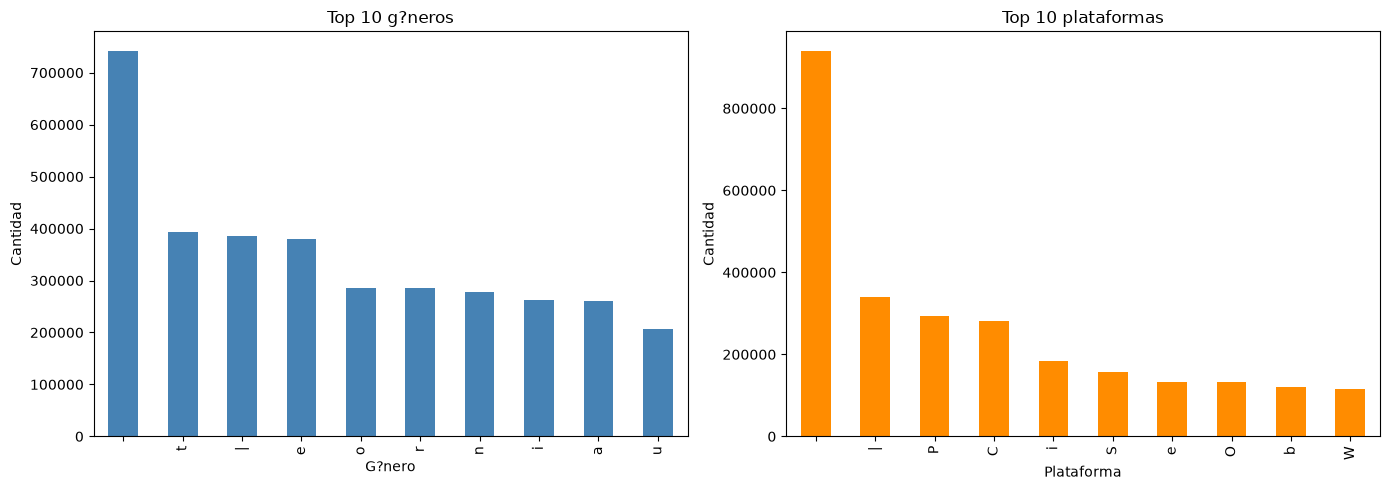

In [4]:
import matplotlib.pyplot as plt

top_genres = df_clean['genres'].dropna().str.split('||').explode().value_counts().head(10)
top_platforms = df_clean['platforms'].dropna().str.split('||').explode().value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top_genres.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 g?neros')
axes[0].set_xlabel('G?nero')
axes[0].set_ylabel('Cantidad')

top_platforms.plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Top 10 plataformas')
axes[1].set_xlabel('Plataforma')
axes[1].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()


In [5]:
output_path = base / 'data' / 'game_info_cleaned.csv'
df_clean.to_csv(output_path, index=False)

summary = {
    'filas': int(df_clean.shape[0]),
    'columnas': int(df_clean.shape[1]),
    'rating_promedio': round(float(df_clean['rating'].mean()), 3),
    'metacritic_promedio': round(float(df_clean['metacritic'].mean()), 3),
    'fecha_min': str(df_clean['released'].min().date()),
    'fecha_max': str(df_clean['released'].max().date()),
}

print('Archivo exportado:', output_path)
print('Resumen general:')
for k, v in summary.items():
    print(f'{k}: {v}')


Archivo exportado: C:\Users\Eric\OneDrive\Desktop\p\U\introduccion-progrmacion-cientifica-\data\game_info_cleaned.csv
Resumen general:
filas: 474417
columnas: 27
rating_promedio: 0.086
metacritic_promedio: 73.159
fecha_min: 1962-01-01
fecha_max: 2033-01-03


In [4]:
# Tier list basada en el rating y un mínimo de 10 reviews
ranked_games = df_clean.loc[
    (df_clean['rating'] > 0) & (df_clean['reviews_count'] >= 10),
    ['name', 'rating', 'reviews_count', 'metacritic', 'released']
].copy()

ranked_games['tier'] = pd.cut(
    ranked_games['rating'],
    bins=[0, 3.5, 4.0, 4.4, 4.7, 5.0],
    labels=['D', 'C', 'B', 'A', 'S'],
    include_lowest=True
)

ranked_games = ranked_games.sort_values(
    ['tier', 'rating', 'reviews_count'],
    ascending=[False, False, False]
)

print(f'Juegos incluidos: {len(ranked_games)}')
for tier in ['S', 'A', 'B', 'C', 'D']:
    print(f'\nTier {tier}')
    display(ranked_games[ranked_games['tier'] == tier].head(10))


Juegos incluidos: 9027

Tier S


,name,rating,reviews_count,metacritic,released,tier
240990,Persona 5 Royal,4.81,123,95.0,2020-03-31,S
158384,The Witcher 3: Game of the Year,4.77,447,92.0,2016-08-30,S
313592,Mass Effect Trilogy,4.76,104,NaN,2012-11-06,S
330908,The Witcher 3: Wild Hunt - Blood and Wine,4.75,336,92.0,2016-05-30,S
11648,METAL GEAR SOLID V: THE DEFINITIVE EXPERIENCE,4.75,24,NaN,2016-10-11,S
328694,The Witcher 3: Wild Hunt - Hearts of Stone,4.74,392,90.0,2015-10-13,S
262524,Yakuza: Like a Dragon,4.73,15,84.0,2020-01-16,S
272183,Grand Theft Auto IV: Complete Edition,4.73,15,95.0,2010-10-27,S



Tier A


,name,rating,reviews_count,metacritic,released,tier
256817,The Last Of Us Remastered,4.70,2148,95.0,2014-07-29,A
279420,Dark Souls III: The Ringed City,4.70,27,83.0,2017-03-28,A
273141,Steven Universe: Unleash the Light,4.70,20,NaN,NaT,A
233307,The Witcher 3: Wild Hunt,4.67,3996,92.0,2015-05-18,A
438280,Mafia II: Director’s Cut,4.67,15,NaN,2011-12-01,A
160858,Final Fantasy VII Remake,4.64,252,87.0,2020-04-10,A
319161,The Elder Scrolls V: Skyrim Legendary Edition,4.64,81,94.0,2013-06-04,A
313921,Star Citizen,4.64,11,NaN,NaT,A
439343,Suikoden V,4.64,11,76.0,2006-02-23,A
317195,Portal 2,4.61,3645,95.0,2011-04-18,A



Tier B


,name,rating,reviews_count,metacritic,released,tier
47907,INSIDE,4.4,1633,87.0,2016-06-28,B
156335,Dark Souls III,4.4,1620,89.0,2016-04-11,B
435675,Fallout: New Vegas,4.4,1558,84.0,2010-10-19,B
471978,Hollow Knight,4.4,1442,88.0,2017-02-23,B
84636,Ori and the Blind Forest: Definitive Edition,4.4,997,88.0,2016-04-27,B
209007,Mafia: The City of Lost Heaven,4.4,720,88.0,2002-08-28,B
135298,Mario Kart 8 Deluxe,4.4,665,92.0,2017-04-27,B
292145,God of War II,4.4,610,NaN,2007-03-13,B
433344,Need for Speed: Underground 2,4.4,607,82.0,2004-11-09,B
430365,Metal Gear Solid 3: Snake Eater,4.4,591,84.0,2004-11-17,B



Tier C


,name,rating,reviews_count,metacritic,released,tier
319379,Terraria,4.0,1394,81.0,2011-05-16,C
87650,DmC: Devil May Cry,4.0,1038,85.0,2013-01-15,C
460428,Tom Clancy's Rainbow Six Siege,4.0,946,75.0,2015-04-07,C
267524,FEZ,4.0,910,91.0,2012-04-13,C
338778,Battlefield 3,4.0,846,86.0,2011-10-25,C
82296,Grim Fandango Remastered,4.0,682,84.0,2015-01-26,C
37938,Game Dev Tycoon,4.0,516,68.0,2012-12-10,C
185044,Gravity Rush Remastered,4.0,238,80.0,2016-02-02,C
82308,Pony Island,4.0,214,86.0,2016-01-04,C
71429,Gunpoint,4.0,212,83.0,2013-06-03,C



Tier D


,name,rating,reviews_count,metacritic,released,tier
126184,Call of Duty: WWII,3.5,712,77.0,2017-11-03,D
266113,Trials Fusion,3.5,475,80.0,2014-04-15,D
166679,Trackmania Turbo,3.5,472,79.0,2016-03-22,D
425552,Oddworld: Abe's Oddysee,3.5,405,NaN,1997-08-31,D
249142,DRIVECLUB,3.5,404,71.0,2014-09-07,D
53134,Alpha Protocol,3.5,325,72.0,2010-04-08,D
23802,Warhammer: End Times - Vermintide,3.5,319,79.0,2015-10-23,D
287432,Aliens vs. Predator (2010),3.5,278,68.0,2010-02-16,D
158128,The Cave,3.5,210,68.0,2013-01-22,D
176542,BIT.TRIP Presents... Runner2: Future Legend of...,3.5,155,85.0,2013-02-25,D


In [5]:
# Tabla estadistica de todos los juegos y mejor puntuacion
estadisticas = df_clean[numericas].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
).T.round(2)
estadisticas.columns = [
    'Cantidad', 'Media', 'Mediana', 'Desv. estandar', 'Minimo', 'Maximo'
]

print('Tabla estadistica de todos los juegos:')
display(estadisticas)

juegos_con_rating = df_clean[df_clean['rating'] > 0].copy()
puntuacion_maxima = juegos_con_rating['rating'].max()
mejor_absoluto = juegos_con_rating[
    juegos_con_rating['rating'] == puntuacion_maxima
][['name', 'rating', 'reviews_count', 'metacritic', 'released']]

print(f'Mayor puntuacion absoluta: {puntuacion_maxima:.2f}/5')
display(mejor_absoluto)

mejor_con_reviews = ranked_games[ranked_games['rating'] == ranked_games['rating'].max()]
print('Mejor valorado con al menos 10 reviews:')
display(mejor_con_reviews)


Tabla estadistica de todos los juegos:


,Cantidad,Media,Mediana,Desv. estandar,Minimo,Maximo
rating,474417.0,0.09,0.0,0.55,0.0,5.0
metacritic,4733.0,73.16,75.0,11.50,15.0,99.0
playtime,474417.0,0.22,0.0,5.40,0.0,1600.0
ratings_count,474417.0,2.14,0.0,36.55,0.0,4289.0
suggestions_count,474417.0,92.20,47.0,116.49,0.0,1839.0
reviews_count,474417.0,2.16,0.0,36.87,0.0,4334.0


Mayor puntuacion absoluta: 5.00/5


,name,rating,reviews_count,metacritic,released
282544,Diablo IV,5.0,6,NaN,NaT


Mejor valorado con al menos 10 reviews:


,name,rating,reviews_count,metacritic,released,tier
240990,Persona 5 Royal,4.81,123,95.0,2020-03-31,S


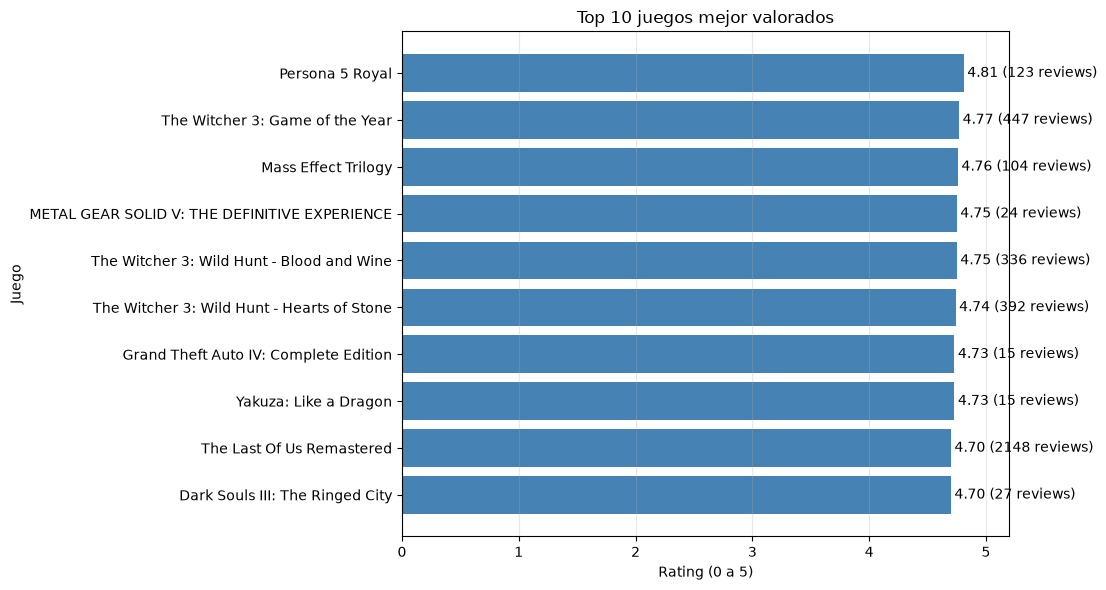

In [6]:
# Grafica de barras de los 10 juegos mejor valorados
top_10 = ranked_games.head(10).sort_values('rating')

fig, ax = plt.subplots(figsize=(11, 6))
barras = ax.barh(top_10['name'], top_10['rating'], color='steelblue')

ax.set_title('Top 10 juegos mejor valorados')
ax.set_xlabel('Rating (0 a 5)')
ax.set_ylabel('Juego')
ax.set_xlim(0, 5.2)
ax.grid(axis='x', alpha=0.3)

for barra, rating, reviews in zip(
    barras, top_10['rating'], top_10['reviews_count']
):
    ax.text(
        barra.get_width() + 0.03,
        barra.get_y() + barra.get_height() / 2,
        f'{rating:.2f} ({reviews} reviews)',
        va='center'
    )

plt.tight_layout()
plt.show()


Datos de Diablo IV:


,name,rating,ratings_count,reviews_count,metacritic,playtime,released,platforms,genres
282544,Diablo IV,5.0,5,6,NaN,0,NaT,Xbox One||PlayStation 4||PC,Action||RPG


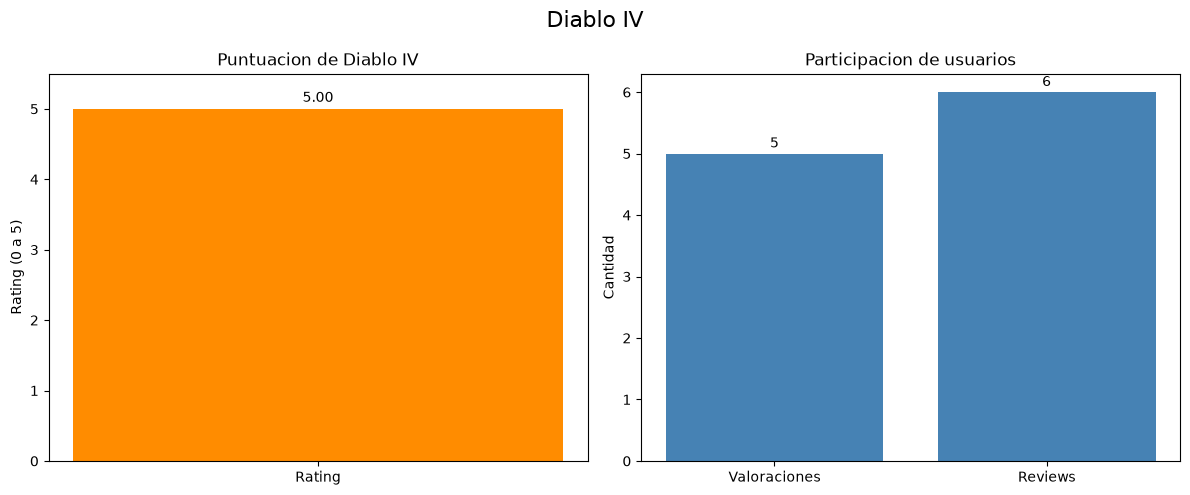

In [7]:
# Datos de Diablo IV en una grafica de barras
diablo_iv = df_clean[df_clean['name'].eq('Diablo IV')].copy()

if diablo_iv.empty:
    print('No se encontro Diablo IV en los datos.')
else:
    juego = diablo_iv.iloc[0]
    datos_diablo = pd.Series({
        'Rating (sobre 5)': juego['rating'],
        'Valoraciones': juego['ratings_count'],
        'Reviews': juego['reviews_count']
    })

    print('Datos de Diablo IV:')
    display(diablo_iv[['name', 'rating', 'ratings_count', 'reviews_count',
                       'metacritic', 'playtime', 'released', 'platforms', 'genres']])

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].bar(['Rating'], [juego['rating']], color='darkorange', width=0.5)
    axes[0].set_title('Puntuacion de Diablo IV')
    axes[0].set_ylabel('Rating (0 a 5)')
    axes[0].set_ylim(0, 5.5)
    axes[0].text(0, juego['rating'] + 0.1, f"{juego['rating']:.2f}", ha='center')

    conteos = [juego['ratings_count'], juego['reviews_count']]
    barras = axes[1].bar(['Valoraciones', 'Reviews'], conteos, color='steelblue')
    axes[1].set_title('Participacion de usuarios')
    axes[1].set_ylabel('Cantidad')
    for barra, valor in zip(barras, conteos):
        axes[1].text(barra.get_x() + barra.get_width() / 2,
                     barra.get_height() + 0.1, str(int(valor)), ha='center')

    fig.suptitle('Diablo IV', fontsize=16)
    plt.tight_layout()
    plt.show()


Juegos evaluados por Metacritic: 4733
Estadisticas del puntaje Metacritic:


,count,mean,std,min,25%,50%,75%,max
Metacritic,4733.0,73.16,11.5,15.0,67.0,75.0,81.0,99.0


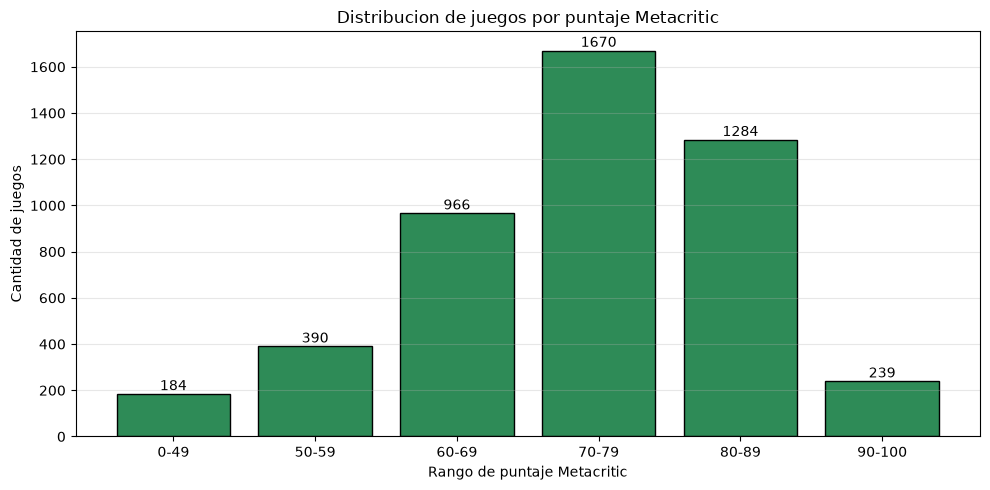

Top 10 juegos segun Metacritic:


,name,metacritic,rating,reviews_count,released
152424,The Legend of Zelda: Ocarina of Time,99.0,4.39,559,1998-11-21
434739,Soulcalibur,98.0,4.37,54,1998-07-30
303629,Soulcalibur (1998),98.0,0.00,0,1998-07-30
245294,Grand Theft Auto V,97.0,4.48,4334,2013-09-17
130701,The Legend of Zelda: Breath of the Wild,97.0,4.56,1952,2017-03-02
180627,Super Mario Odyssey,97.0,4.43,1282,2017-10-26
170762,Super Mario Galaxy,97.0,4.39,479,2007-11-12
170882,Super Mario Galaxy 2,97.0,4.36,252,2010-05-23
436205,Metroid Prime,97.0,4.38,167,2002-11-17
185167,Perfect Dark,97.0,3.99,122,2000-05-22


Principales hallazgos:
- El puntaje promedio de Metacritic es 73.16.
- El rango mas frecuente es 70-79, con 1670 juegos.
- El 32.18% de los juegos tiene un puntaje de 80 o superior.
Conclusion: la mayor concentracion de juegos se encuentra en los puntajes intermedios;
los juegos con 80 o mas representan los titulos mejor evaluados por la critica.


In [8]:
# Analisis estadistico de Metacritic para todos los juegos evaluados
metacritic_games = df_clean[df_clean['metacritic'].notna()].copy()

rangos_metacritic = pd.cut(
    metacritic_games['metacritic'],
    bins=[0, 49, 59, 69, 79, 89, 100],
    labels=['0-49', '50-59', '60-69', '70-79', '80-89', '90-100'],
    include_lowest=True
).value_counts().sort_index()

estadisticas_metacritic = metacritic_games['metacritic'].describe().to_frame().T.round(2)
estadisticas_metacritic.index = ['Metacritic']
print(f'Juegos evaluados por Metacritic: {len(metacritic_games)}')
print('Estadisticas del puntaje Metacritic:')
display(estadisticas_metacritic)

fig, ax = plt.subplots(figsize=(10, 5))
barras = ax.bar(rangos_metacritic.index, rangos_metacritic.values,
                color='seagreen', edgecolor='black')
ax.set_title('Distribucion de juegos por puntaje Metacritic')
ax.set_xlabel('Rango de puntaje Metacritic')
ax.set_ylabel('Cantidad de juegos')
ax.grid(axis='y', alpha=0.3)

for barra, cantidad in zip(barras, rangos_metacritic.values):
    ax.text(barra.get_x() + barra.get_width() / 2,
            barra.get_height() + max(rangos_metacritic.values) * 0.01,
            str(cantidad), ha='center')

plt.tight_layout()
plt.show()

print('Top 10 juegos segun Metacritic:')
top_metacritic = metacritic_games.sort_values(
    ['metacritic', 'reviews_count'], ascending=[False, False]
).head(10)
display(top_metacritic[['name', 'metacritic', 'rating', 'reviews_count', 'released']])

puntaje_medio = metacritic_games['metacritic'].mean()
porcentaje_altos = (metacritic_games['metacritic'] >= 80).mean() * 100
rango_mas_frecuente = rangos_metacritic.idxmax()
print('Principales hallazgos:')
print(f'- El puntaje promedio de Metacritic es {puntaje_medio:.2f}.')
print(f'- El rango mas frecuente es {rango_mas_frecuente}, con {rangos_metacritic.max()} juegos.')
print(f'- El {porcentaje_altos:.2f}% de los juegos tiene un puntaje de 80 o superior.')
print('Conclusion: la mayor concentracion de juegos se encuentra en los puntajes intermedios;')
print('los juegos con 80 o mas representan los titulos mejor evaluados por la critica.')
